<a href="https://colab.research.google.com/github/keshiniPaul/Ecommerce-purchase-prediction-DeepLearning/blob/Keshini/notebooks/Transformer_RetailRocket_Keshini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/keshiniPaul/Ecommerce-purchase-prediction-DeepLearning.git

Cloning into 'Ecommerce-purchase-prediction-DeepLearning'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [ ]:
%cd /content/Ecommerce-purchase-prediction-DeepLearning

/content/Ecommerce-purchase-prediction-DeepLearning


In [ ]:
!git branch

* main


In [ ]:
!git checkout Keshini

branch 'Keshini' set up to track 'origin/Keshini'.
Switched to a new branch 'Keshini'


In [ ]:
!git branch

* Keshini
  main


In [ ]:
!mkdir -p notebooks
!mkdir -p results/figures
!mkdir -p results/metrics
!mkdir -p models
!mkdir -p src/transformer

In [ ]:
!find . -maxdepth 3 -type d

.
./results
./results/figures
./results/metrics
./.git
./.git/refs
./.git/refs/remotes
./.git/refs/tags
./.git/refs/heads
./.git/objects
./.git/objects/info
./.git/objects/pack
./.git/branches
./.git/info
./.git/hooks
./.git/logs
./.git/logs/refs
./models
./notebooks
./src
./src/transformer


# Transformer Based Purchase Prediction Using the RetailRocket Dataset

**Student:** Keshini Paul  
**Student ID:** IT23206496  
**Module:** SE4050 Deep Learning  
**Model:** Transformer Encoder  
**Problem:** Session level purchase prediction

## Project Objective

This project investigates supervised deep learning models for predicting whether a user session on an e-commerce platform will result in a purchase.

The RetailRocket e-commerce dataset is used for the analysis. This notebook focuses on the Transformer Encoder model. The model will learn patterns from user interaction sequences such as product views and add to cart events to estimate the probability of a purchase.

The preprocessing and evaluation methodology will follow the common methodology agreed by the project group so that the four deep learning models can be compared using consistent data preparation, training, and evaluation procedures.

In [ ]:
# ============================================
# Project Configuration
# ============================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Random seed:", SEED)
print("Project configuration loaded successfully.")

Random seed: 42
Project configuration loaded successfully.


In [ ]:
!git status

On branch Keshini
Your branch is up to date with 'origin/Keshini'.

nothing to commit, working tree clean


In [ ]:
!pwd

/content/Ecommerce-purchase-prediction-DeepLearning


In [ ]:
!ls -la notebooks

total 8
drwxr-xr-x 2 root root 4096 Sep 25 18:15 .
drwxr-xr-x 7 root root 4096 Sep 25 18:15 ..


In [ ]:
!git status

On branch Keshini
Your branch is up to date with 'origin/Keshini'.

nothing to commit, working tree clean


In [ ]:
!git log --oneline -3

a76b6e2 (HEAD -> Keshini, origin/main, origin/Sheran, origin/Keshini, origin/Hansani, origin/HEAD, origin/Anushika, main) Initial commit


In [ ]:
!ls -la notebooks

total 8
drwxr-xr-x 2 root root 4096 Sep 25 18:15 .
drwxr-xr-x 7 root root 4096 Sep 25 18:15 ..


In [ ]:
!ls -la notebooks

total 8
drwxr-xr-x 2 root root 4096 Sep 25 18:15 .
drwxr-xr-x 7 root root 4096 Sep 25 18:15 ..


In [ ]:
!git pull origin Keshini

remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 8 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (8/8), 3.24 KiB | 1.08 MiB/s, done.
From https://github.com/keshiniPaul/Ecommerce-purchase-prediction-DeepLearning
 * branch            Keshini    -> FETCH_HEAD
   a76b6e2..6f44197  Keshini    -> origin/Keshini
Updating a76b6e2..6f44197
Fast-forward
 notebooks/Transformer_RetailRocket_Keshini.ipynb | 428 +++++++++++++++++++++++
 1 file changed, 428 insertions(+)
 create mode 100644 notebooks/Transformer_RetailRocket_Keshini.ipynb


In [ ]:
!ls -la notebooks

total 20
drwxr-xr-x 2 root root  4096 Sep 25 18:38 .
drwxr-xr-x 7 root root  4096 Sep 25 18:15 ..
-rw-r--r-- 1 root root 11848 Sep 25 18:38 Transformer_RetailRocket_Keshini.ipynb


In [ ]:
!git status

On branch Keshini
Your branch is up to date with 'origin/Keshini'.

nothing to commit, working tree clean


## Dataset

The RetailRocket e-commerce dataset is used as the primary dataset for this project. The dataset contains user interaction events, including product views, add to cart events, and transaction events.

The `events.csv` file is stored in Google Drive and will be loaded into the notebook for initial exploration and subsequent preprocessing.

In [ ]:
# ============================================
# Mount Google Drive
# ============================================

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================
# Dataset Path
# ============================================

DATA_PATH = "/content/drive/MyDrive/SE4050_RetailRocket/data/events.csv"

print("Dataset path:", DATA_PATH)

Dataset path: /content/drive/MyDrive/SE4050_RetailRocket/data/events.csv


In [ ]:
import os

print("File exists:", os.path.exists(DATA_PATH))

File exists: True


In [ ]:
DATA_PATH = "/content/drive/MyDrive/SE4050/RetailRocket/events.csv"

In [ ]:
import os

print("Dataset path:", DATA_PATH)
print("File exists:", os.path.exists(DATA_PATH))

Dataset path: /content/drive/MyDrive/SE4050/RetailRocket/events.csv
File exists: False


In [ ]:
import os

print("Dataset path:", DATA_PATH)
print("File exists:", os.path.exists(DATA_PATH))

Dataset path: /content/drive/MyDrive/SE4050/RetailRocket/events.csv
File exists: False


In [ ]:
import os

print("Dataset path:", DATA_PATH)
print("File exists:", os.path.exists(DATA_PATH))

Dataset path: /content/drive/MyDrive/SE4050/RetailRocket/events.csv
File exists: False


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'BM21574368-TEMPID.pdf', 'Data analysis results', 'Keshini Paul (With Watermark) 6 (With Watermark) (With Watermark).pdf', 'URF-14.mp4', 'URF-14', 'payment (batch photo).jpeg', 'video-output-F66234B9-01E5-42D3-B833-B81E00428A1C-1.mov', 'HCI Video final', 'IT2070-Data Structures and Algorithms.pdf', 'IT2070-Data Structures and Algorithms.gdoc', 'Keshini Antoinette Paul CV.pdf', '2025 June ITPM.pdf', '2024 June ITPM.pdf', '2024 PAF.pdf', '2024 June DS.pdf', '2024 June NDM.pdf', '2024 June DS.gdoc', '2024 June NDM.gdoc', '2024 PAF.gdoc', '2024 June ITPM.gdoc', '2025 June ITPM.gdoc', 'Untitled document (1).gdoc', 'Untitled document.gdoc', 'New-NDM All in One.gdoc', 'Lab 4 DL', 'SE4050_RetailRocket']


In [ ]:
'))print(os.listdir('/content/drive/MyDrive/SE4050_RetailRocket

['data']


In [ ]:
print(os.listdir('/content/drive/MyDrive/SE4050_RetailRocket/data'))

['events.csv']


In [ ]:
import os

DATA_PATH = "/content/drive/MyDrive/SE4050_RetailRocket/data/events.csv"

print("Dataset path:", DATA_PATH)
print("File exists:", os.path.exists(DATA_PATH))

Dataset path: /content/drive/MyDrive/SE4050_RetailRocket/data/events.csv
File exists: True


In [ ]:
DATA_PATH = "/content/drive/MyDrive/SE4050_RetailRocket/data/events.csv"

print("Dataset path:", DATA_PATH)

Dataset path: /content/drive/MyDrive/SE4050_RetailRocket/data/events.csv


In [ ]:
events = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", events.shape)

Dataset loaded successfully.
Shape: (2756101, 5)


In [ ]:
events.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [ ]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB


In [ ]:
print("Columns:")
print(events.columns.tolist())

Columns:
['timestamp', 'visitorid', 'event', 'itemid', 'transactionid']


In [ ]:
print("Missing values:")
print(events.isnull().sum())

Missing values:
timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64


In [ ]:
print("Number of duplicate rows:", events.duplicated().sum())

Number of duplicate rows: 460


In [ ]:
event_counts = events["event"].value_counts()

print(event_counts)

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64


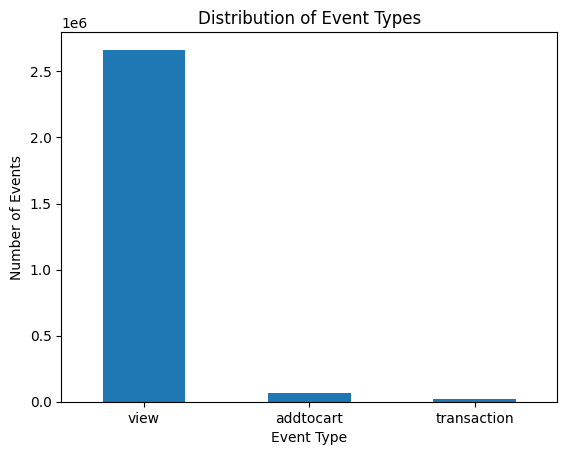

In [ ]:
event_counts.plot(kind="bar")

plt.title("Distribution of Event Types")
plt.xlabel("Event Type")
plt.ylabel("Number of Events")
plt.xticks(rotation=0)
plt.show()

In [ ]:
print("Unique visitors:", events["visitorid"].nunique())
print("Unique items:", events["itemid"].nunique())

Unique visitors: 1407580
Unique items: 235061


In [ ]:
print("Minimum timestamp:", events["timestamp"].min())
print("Maximum timestamp:", events["timestamp"].max())

Minimum timestamp: 1430622004384
Maximum timestamp: 1442545187788


In [ ]:
!git status

On branch Keshini
Your branch is up to date with 'origin/Keshini'.

nothing to commit, working tree clean


In [ ]:
!git pull origin Keshini

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 4 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 23.28 KiB | 5.82 MiB/s, done.
From https://github.com/keshiniPaul/Ecommerce-purchase-prediction-DeepLearning
 * branch            Keshini    -> FETCH_HEAD
   6f44197..b22cb0f  Keshini    -> origin/Keshini
Updating 6f44197..b22cb0f
Fast-forward
 notebooks/Transformer_RetailRocket_Keshini.ipynb | 898 ++++++++++++++++++++++-
 1 file changed, 897 insertions(+), 1 deletion(-)


In [ ]:
!git status

On branch Keshini
Your branch is up to date with 'origin/Keshini'.

nothing to commit, working tree clean


In [ ]:
!git log --oneline -3

b22cb0f (HEAD -> Keshini, origin/Keshini) Add RetailRocket dataset loading and initial inspection.
6f44197 Initialize Transformer project structure
d16a473 Initialize Transformer project structure


## Data Cleaning and Timestamp Processing

The RetailRocket event data is cleaned before session construction. Missing `transactionid` values are retained because transaction identifiers are naturally absent for non-purchase events such as product views and add-to-cart interactions.

Exact duplicate records are removed, timestamps are converted from Unix milliseconds into datetime values, invalid timestamps are removed, and the events are sorted chronologically for each visitor.

In [2]:
import os

print(os.path.exists("/content/drive/MyDrive/SE4050_RetailRocket/data/events.csv"))

False


In [4]:
# ============================================
# Load RetailRocket Dataset
# ============================================

from google.colab import drive
import os
import pandas as pd

drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/SE4050_RetailRocket/data/events.csv"

print("Dataset path:", DATA_PATH)
print("File exists:", os.path.exists(DATA_PATH))

events = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", events.shape)

Mounted at /content/drive
Dataset path: /content/drive/MyDrive/SE4050_RetailRocket/data/events.csv
File exists: True
Dataset loaded successfully.
Shape: (2756101, 5)


In [5]:
print("events variable exists:", "events" in globals())
print("Dataset shape:", events.shape)

events variable exists: True
Dataset shape: (2756101, 5)


In [6]:
# ============================================
# Data Cleaning
# ============================================

events_clean = events.copy()

print("Original shape:", events_clean.shape)

Original shape: (2756101, 5)


In [7]:
print("Event types:")
print(events_clean["event"].value_counts(dropna=False))

Event types:
event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64


In [8]:
duplicates_before = events_clean.duplicated().sum()

events_clean = events_clean.drop_duplicates().copy()

duplicates_after = events_clean.duplicated().sum()

print("Duplicate rows before cleaning:", duplicates_before)
print("Duplicate rows after cleaning:", duplicates_after)

Duplicate rows before cleaning: 460
Duplicate rows after cleaning: 0


In [9]:
events_clean["datetime"] = pd.to_datetime(
    events_clean["timestamp"],
    unit="ms",
    errors="coerce"
)

In [10]:
print(
    "Invalid timestamps:",
    events_clean["datetime"].isna().sum()
)

Invalid timestamps: 0


In [11]:
events_clean = events_clean.sort_values(
    ["visitorid", "datetime"]
).reset_index(drop=True)

In [12]:
events_clean.head()

,timestamp,visitorid,event,itemid,transactionid,datetime
0,1442004589439,0,view,285930,NaN,2015-09-11 20:49:49.439
1,1442004759591,0,view,357564,NaN,2015-09-11 20:52:39.591
2,1442004917175,0,view,67045,NaN,2015-09-11 20:55:17.175
3,1439487966444,1,view,72028,NaN,2015-08-13 17:46:06.444
4,1438969904567,2,view,325215,NaN,2015-08-07 17:51:44.567


In [13]:
events_clean = events_clean[
    [
        "timestamp",
        "datetime",
        "visitorid",
        "event",
        "itemid",
        "transactionid"
    ]
].copy()

In [14]:
print("Cleaned shape:", events_clean.shape)
print("Columns:", events_clean.columns.tolist())

events_clean.head()

Cleaned shape: (2755641, 6)
Columns: ['timestamp', 'datetime', 'visitorid', 'event', 'itemid', 'transactionid']


,timestamp,datetime,visitorid,event,itemid,transactionid
0,1442004589439,2015-09-11 20:49:49.439,0,view,285930,NaN
1,1442004759591,2015-09-11 20:52:39.591,0,view,357564,NaN
2,1442004917175,2015-09-11 20:55:17.175,0,view,67045,NaN
3,1439487966444,2015-08-13 17:46:06.444,1,view,72028,NaN
4,1438969904567,2015-08-07 17:51:44.567,2,view,325215,NaN


In [19]:
!git clone https://github.com/keshiniPaul/Ecommerce-purchase-prediction-DeepLearning.git

Cloning into 'Ecommerce-purchase-prediction-DeepLearning'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 19 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 30.28 KiB | 10.09 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [20]:
%cd /content/Ecommerce-purchase-prediction-DeepLearning

/content/Ecommerce-purchase-prediction-DeepLearning


In [21]:
!git checkout Keshini

branch 'Keshini' set up to track 'origin/Keshini'.
Switched to a new branch 'Keshini'


In [22]:
!git status

On branch Keshini
Your branch is up to date with 'origin/Keshini'.

nothing to commit, working tree clean


In [23]:
!git log --oneline -5

461ae6e (HEAD -> Keshini, origin/Keshini) Implement event cleaning and timestamp preprocessing.
b22cb0f Add RetailRocket dataset loading and initial inspection.
6f44197 Initialize Transformer project structure
d16a473 Initialize Transformer project structure
a76b6e2 (origin/main, origin/Sheran, origin/Hansani, origin/HEAD, origin/Anushika, main) Initial commit


In [24]:
print("events_clean exists:", "events_clean" in globals())

events_clean exists: True


## 30-Minute Sessionization

A session is defined as a sequence of events from the same visitor where the gap between consecutive events is no more than 30 minutes. A new session begins when the time gap between consecutive events from the same visitor is greater than 30 minutes.

This sessionization rule is applied consistently across the project to prepare ordered user interaction sequences for the deep learning models.

In [25]:
# ============================================
# Sessionization
# ============================================

events_clean["previous_datetime"] = (
    events_clean
    .groupby("visitorid")["datetime"]
    .shift(1)
)

events_clean.head()

,timestamp,datetime,visitorid,event,itemid,transactionid,previous_datetime
0,1442004589439,2015-09-11 20:49:49.439,0,view,285930,NaN,NaT
1,1442004759591,2015-09-11 20:52:39.591,0,view,357564,NaN,2015-09-11 20:49:49.439
2,1442004917175,2015-09-11 20:55:17.175,0,view,67045,NaN,2015-09-11 20:52:39.591
3,1439487966444,2015-08-13 17:46:06.444,1,view,72028,NaN,NaT
4,1438969904567,2015-08-07 17:51:44.567,2,view,325215,NaN,NaT


In [26]:
events_clean["time_gap_seconds"] = (
    events_clean["datetime"] -
    events_clean["previous_datetime"]
).dt.total_seconds()

In [27]:
events_clean[
    [
        "visitorid",
        "datetime",
        "previous_datetime",
        "time_gap_seconds"
    ]
].head(10)

,visitorid,datetime,previous_datetime,time_gap_seconds
0,0,2015-09-11 20:49:49.439,NaT,NaN
1,0,2015-09-11 20:52:39.591,2015-09-11 20:49:49.439,170.152
2,0,2015-09-11 20:55:17.175,2015-09-11 20:52:39.591,157.584
3,1,2015-08-13 17:46:06.444,NaT,NaN
4,2,2015-08-07 17:51:44.567,NaT,NaN
5,2,2015-08-07 17:53:33.790,2015-08-07 17:51:44.567,109.223
6,2,2015-08-07 17:56:52.664,2015-08-07 17:53:33.790,198.874
7,2,2015-08-07 18:01:08.920,2015-08-07 17:56:52.664,256.256
8,2,2015-08-07 18:08:25.669,2015-08-07 18:01:08.920,436.749
9,2,2015-08-07 18:17:24.375,2015-08-07 18:08:25.669,538.706


In [28]:
SESSION_GAP_SECONDS = 30 * 60

print(
    "Session inactivity threshold:",
    SESSION_GAP_SECONDS,
    "seconds"
)

Session inactivity threshold: 1800 seconds


In [29]:
events_clean["new_session"] = (
    events_clean["previous_datetime"].isna() |
    (events_clean["time_gap_seconds"] > SESSION_GAP_SECONDS)
)

In [30]:
events_clean["session_number"] = (
    events_clean
    .groupby("visitorid")["new_session"]
    .cumsum()
)

In [31]:
events_clean["session_id"] = (
    events_clean["visitorid"].astype(str)
    + "_"
    + events_clean["session_number"].astype(str)
)

In [32]:
events_clean[
    [
        "visitorid",
        "datetime",
        "event",
        "time_gap_seconds",
        "new_session",
        "session_id"
    ]
].head(20)

,visitorid,datetime,event,time_gap_seconds,new_session,session_id
0,0,2015-09-11 20:49:49.439,view,NaN,True,0_1
1,0,2015-09-11 20:52:39.591,view,170.152,False,0_1
2,0,2015-09-11 20:55:17.175,view,157.584,False,0_1
3,1,2015-08-13 17:46:06.444,view,NaN,True,1_1
4,2,2015-08-07 17:51:44.567,view,NaN,True,2_1
5,2,2015-08-07 17:53:33.790,view,109.223,False,2_1
6,2,2015-08-07 17:56:52.664,view,198.874,False,2_1
7,2,2015-08-07 18:01:08.920,view,256.256,False,2_1
8,2,2015-08-07 18:08:25.669,view,436.749,False,2_1
9,2,2015-08-07 18:17:24.375,view,538.706,False,2_1


In [33]:
number_of_sessions = events_clean["session_id"].nunique()

print("Number of sessions:", number_of_sessions)

Number of sessions: 1761675


In [34]:
session_lengths = (
    events_clean
    .groupby("session_id")
    .size()
)

print(session_lengths.describe())

count    1.761675e+06
mean     1.564216e+00
std      2.599172e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      4.170000e+02
dtype: float64


In [35]:
print("Number of sessions:", events_clean["session_id"].nunique())
print("Total events:", len(events_clean))
print("Session ID missing:", events_clean["session_id"].isna().sum())

Number of sessions: 1761675
Total events: 2755641
Session ID missing: 0


In [36]:
%cd /content/Ecommerce-purchase-prediction-DeepLearning

/content/Ecommerce-purchase-prediction-DeepLearning


In [37]:
!git pull origin Keshini

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 4 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 4.61 KiB | 590.00 KiB/s, done.
From https://github.com/keshiniPaul/Ecommerce-purchase-prediction-DeepLearning
 * branch            Keshini    -> FETCH_HEAD
   461ae6e..e387666  Keshini    -> origin/Keshini
Updating 461ae6e..e387666
Fast-forward
 notebooks/Transformer_RetailRocket_Keshini.ipynb | 1173 +++++++++++++++++++++-
 1 file changed, 1172 insertions(+), 1 deletion(-)


In [38]:
!git log --oneline -4

e387666 (HEAD -> Keshini, origin/Keshini) Implement 30-minute inactivity sessionization.
461ae6e Implement event cleaning and timestamp preprocessing.
b22cb0f Add RetailRocket dataset loading and initial inspection.
6f44197 Initialize Transformer project structure


In [39]:
!git status

On branch Keshini
Your branch is up to date with 'origin/Keshini'.

nothing to commit, working tree clean


In [40]:
print("events_clean exists:", "events_clean" in globals())

events_clean exists: True


## Purchase Labels and Leakage Prevention

In [41]:
# ============================================
# Purchase Labels
# ============================================

session_labels = (
    events_clean
    .groupby("session_id")["event"]
    .apply(lambda x: int((x == "transaction").any()))
    .rename("target")
)

print(session_labels.value_counts())

target
0    1747378
1      14297
Name: count, dtype: int64


In [42]:
events_clean = events_clean.merge(
    session_labels,
    on="session_id",
    how="left"
)

In [43]:
events_clean[
    ["session_id", "event", "target"]
].head(20)

,session_id,event,target
0,0_1,view,0
1,0_1,view,0
2,0_1,view,0
3,1_1,view,0
4,2_1,view,0
5,2_1,view,0
6,2_1,view,0
7,2_1,view,0
8,2_1,view,0
9,2_1,view,0


In [44]:
transaction_times = (
    events_clean[
        events_clean["event"] == "transaction"
    ]
    .groupby("session_id")["datetime"]
    .min()
    .rename("first_transaction_time")
)

events_clean = events_clean.merge(
    transaction_times,
    on="session_id",
    how="left"
)

In [45]:
events_clean["before_first_transaction"] = (
    events_clean["first_transaction_time"].isna()
    |
    (events_clean["datetime"] < events_clean["first_transaction_time"])
)

In [46]:
model_events = events_clean[
    events_clean["before_first_transaction"]
    &
    events_clean["event"].isin(["view", "addtocart"])
].copy()

In [47]:
print(model_events["event"].value_counts())

event
view         2623226
addtocart      63445
Name: count, dtype: int64


In [48]:
print(
    "Transaction events in model input:",
    (model_events["event"] == "transaction").sum()
)

Transaction events in model input: 0


In [49]:
session_model_data = (
    model_events[
        [
            "session_id",
            "visitorid",
            "event",
            "itemid",
            "datetime",
            "target"
        ]
    ]
    .copy()
)

session_model_data.head()

,session_id,visitorid,event,itemid,datetime,target
0,0_1,0,view,285930,2015-09-11 20:49:49.439,0
1,0_1,0,view,357564,2015-09-11 20:52:39.591,0
2,0_1,0,view,67045,2015-09-11 20:55:17.175,0
3,1_1,1,view,72028,2015-08-13 17:46:06.444,0
4,2_1,2,view,325215,2015-08-07 17:51:44.567,0


In [50]:
model_session_labels = (
    session_model_data
    .groupby("session_id")["target"]
    .first()
)

print(model_session_labels.value_counts())

target
0    1747378
1      13359
Name: count, dtype: int64


In [51]:
print(
    "Positive sessions:",
    (model_session_labels == 1).sum()
)

print(
    "Negative sessions:",
    (model_session_labels == 0).sum()
)

Positive sessions: 13359
Negative sessions: 1747378


In [52]:
all_session_labels = session_labels

model_session_ids = set(
    model_session_labels.index
)

missing_input_sessions = set(
    all_session_labels.index
) - model_session_ids

print(
    "Sessions with no usable pre-purchase input events:",
    len(missing_input_sessions)
)

Sessions with no usable pre-purchase input events: 938


In [53]:
print("Total modelling events:", len(model_events))
print(
    "Transaction events in model input:",
    (model_events["event"] == "transaction").sum()
)
print("Positive sessions:", (model_session_labels == 1).sum())
print("Negative sessions:", (model_session_labels == 0).sum())
print(
    "Sessions with no usable pre-purchase input events:",
    len(missing_input_sessions)
)

Total modelling events: 2686671
Transaction events in model input: 0
Positive sessions: 13359
Negative sessions: 1747378
Sessions with no usable pre-purchase input events: 938
